#### Tyre Degradation
###### 1.This notebooks contains the code for dataset creation for Tyre Degradation.
###### 2.Plotting degradation curves
###### 3. Testing Linear Vs Non-linear behaviour

In [2]:
import pandas as pd 
driver_df = pd.read_csv("C:/Users/VANSH/Formula1/datasets/2024/raw_driver_2024.csv")

In [9]:
def time_to_seconds(x):

    if pd.isna(x):
        return None

    try:
        return pd.to_timedelta(x).total_seconds()

    except:
        return None

In [10]:
def clean_driver_data_degrad(driver_df):

    # Make copy
    cleaned_df = driver_df.copy()

    # -------------------------
    # Convert time columns
    # -------------------------

    time_cols = [
        'LapTime',
        'Sector1Time',
        'Sector2Time',
        'Sector3Time'
    ]

    for col in time_cols:

        cleaned_df[col] = cleaned_df[col].apply(
            time_to_seconds
        )

    # -------------------------
    # Drop missing LapTime/Compound
    # -------------------------

    before_drop = cleaned_df.shape[0]

    cleaned_df = cleaned_df.dropna(
        subset=['LapTime', 'Compound']
    )

    print(
        f"Dropped {before_drop - cleaned_df.shape[0]} rows "
        f"with missing LapTime/Compound"
    )

    # -------------------------
    # Handle TyreLife
    # -------------------------

    missing_tyre = cleaned_df['TyreLife'].isna().sum()

    cleaned_df['TyreLife'] = (
        cleaned_df['TyreLife']
        .fillna(0)
        .astype(int)
    )

    print(
        f"Filled {missing_tyre} missing TyreLife values with 0"
    )

    # -------------------------
    # Handle FreshTyre
    # -------------------------

    missing_fresh = cleaned_df['FreshTyre'].isna().sum()

    cleaned_df['FreshTyre'] = (
        cleaned_df['FreshTyre']
        .fillna(False)
        .astype(int)
    )

    print(
        f"Filled {missing_fresh} missing FreshTyre values with False"
    )

    # -------------------------
    # Preserve degradation columns
    # -------------------------

    degradation_cols = [
        'TrackStatus',
        'PitInTime',
        'PitOutTime',
        'Deleted',
        'DeletedReason',
        'IsAccurate'
    ]

    existing_cols = [
        col for col in degradation_cols
        if col in cleaned_df.columns
    ]

    print(
        f"Preserved degradation columns: "
        f"{existing_cols}"
    )

    # -------------------------
    # Reset index
    # -------------------------

    cleaned_df = cleaned_df.reset_index(
        drop=True
    )
    cleaned_df.to_csv(
    "C:/Users/VANSH/Formula1/datasets/2024/degrad_cleaned_driver_2024.csv", index=False)
    print("Cleaned driver data saved to 'degrad_cleaned_driver_2024.csv'")
    return cleaned_df
    

In [11]:
cleaned_driver_df = clean_driver_data_degrad(driver_df)

Dropped 8260 rows with missing LapTime/Compound
Filled 14 missing TyreLife values with 0
Filled 0 missing FreshTyre values with False
Preserved degradation columns: ['TrackStatus', 'PitInTime', 'PitOutTime', 'Deleted', 'DeletedReason', 'IsAccurate']
Cleaned driver data saved to 'degrad_cleaned_driver_2024.csv'


['Time',
 'Driver',
 'DriverNumber',
 'LapTime',
 'LapNumber',
 'Stint',
 'PitOutTime',
 'PitInTime',
 'Sector1Time',
 'Sector2Time',
 'Sector3Time',
 'Sector1SessionTime',
 'Sector2SessionTime',
 'Sector3SessionTime',
 'SpeedI1',
 'SpeedI2',
 'SpeedFL',
 'SpeedST',
 'IsPersonalBest',
 'Compound',
 'TyreLife',
 'FreshTyre',
 'Team',
 'LapStartTime',
 'LapStartDate',
 'TrackStatus',
 'Position',
 'Deleted',
 'DeletedReason',
 'FastF1Generated',
 'IsAccurate',
 'RoundNumber',
 'GP',
 'Session',
 'Date']

In [15]:
import pandas as pd

# Load cleaned degradation dataset
df = pd.read_csv(
    "C:/Users/VANSH/Formula1/datasets/2024/degrad_cleaned_driver_2024.csv"
)

print("Before filtering:", len(df))

# Race laps only
degradation_df = df[
    df["Session"] == "R"
].copy()

# Accurate laps only
degradation_df = degradation_df[
    degradation_df["IsAccurate"] == True
]

# Remove deleted laps
degradation_df = degradation_df[
    degradation_df["Deleted"] == False
]

# Remove pit-in laps
degradation_df = degradation_df[
    degradation_df["PitInTime"].isna()
]

# Remove pit-out laps
degradation_df = degradation_df[
    degradation_df["PitOutTime"].isna()
]

# Green flag laps only
degradation_df = degradation_df[
    degradation_df["TrackStatus"].astype(str) == "1"
]

print("After filtering:", len(degradation_df))
print("Removed:", len(df) - len(degradation_df))

degradation_df.to_csv(
    "degradation_dataset_2024_v1.csv",
    index=False
)

print("Saved: degradation_dataset_2024_v1.csv")

Before filtering: 52010
After filtering: 22719
Removed: 29291
Saved: degradation_dataset_2024_v1.csv


#### Plotting 

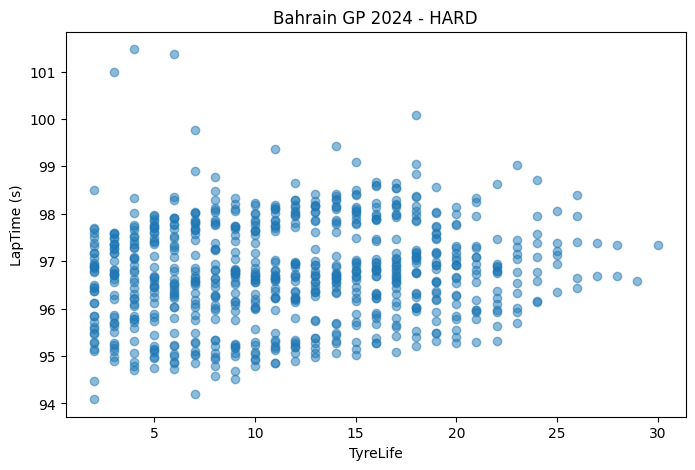

Rows plotted: 719


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "degradation_dataset_2024_v1.csv"
)

sample = df[
    (df["GP"] == "Bahrain Grand Prix") &
    (df["Compound"] == "HARD")
].copy()

plt.figure(figsize=(8, 5))

plt.scatter(
    sample["TyreLife"],
    sample["LapTime"],
    alpha=0.5
)

plt.xlabel("TyreLife")
plt.ylabel("LapTime (s)")
plt.title("Bahrain GP 2024 - HARD")

plt.show()

print("Rows plotted:", len(sample))

##### Bahrain GP Verstappen Hard Compound

Stint
2.0    18
dtype: int64


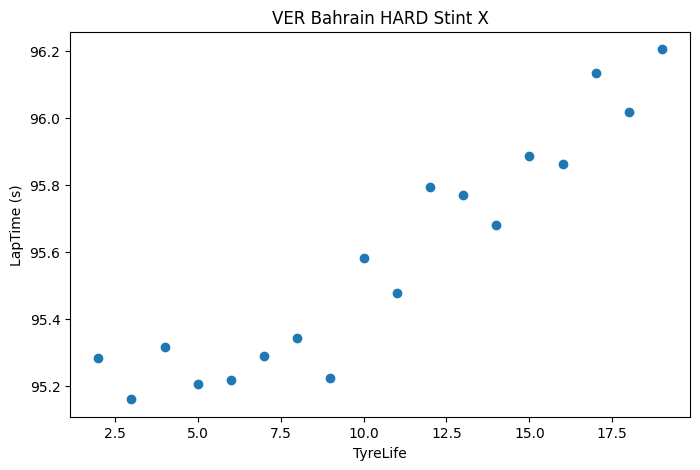

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "degradation_dataset_2024_v1.csv"
)

sample = df[
    (df["GP"] == "Bahrain Grand Prix") &
    (df["Driver"] == "VER") &
    (df["Compound"] == "HARD")
]

print(
    sample.groupby("Stint")
    .size()
    .sort_values(ascending=False)
)


stint_df = sample[
    sample["Stint"] == 2  # replace X
]

plt.figure(figsize=(8,5))

plt.scatter(
    stint_df["TyreLife"],
    stint_df["LapTime"]
)

plt.xlabel("TyreLife")
plt.ylabel("LapTime (s)")
plt.title(
    "VER Bahrain HARD Stint X"
)

plt.show()

##### Bahrain GP VER Medium Compound

Stint
3.0    18
1.0    13
dtype: int64


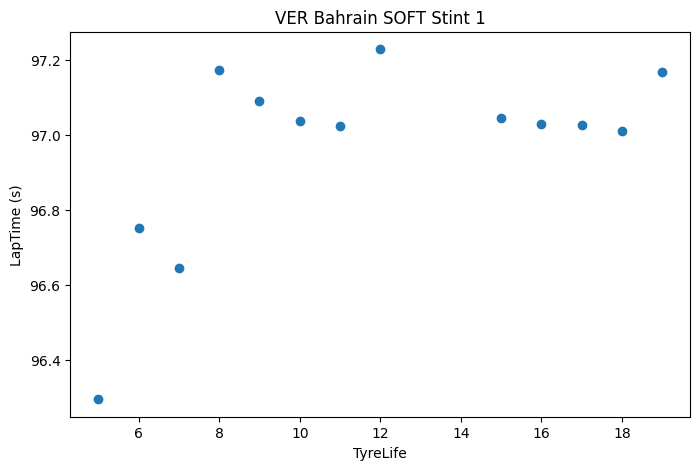

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "degradation_dataset_2024_v1.csv"
)

sample = df[
    (df["GP"] == "Bahrain Grand Prix") &
    (df["Driver"] == "VER") &
    (df["Compound"] == "SOFT")
]

print(
    sample.groupby("Stint")
    .size()
    .sort_values(ascending=False)
)


stint_df = sample[
    sample["Stint"] == 1  # replace X
]

plt.figure(figsize=(8,5))

plt.scatter(
    stint_df["TyreLife"],
    stint_df["LapTime"]
)

plt.xlabel("TyreLife")
plt.ylabel("LapTime (s)")
plt.title(
    "VER Bahrain SOFT Stint 1"
)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("degradation_dataset_2024_v1.csv")

def plot_longest_stint(gp, compound):

    sample = df[
        (df["GP"] == gp) &
        (df["Compound"] == compound)
    ]

    stint_lengths = (
        sample.groupby(
            ["Driver", "Stint"]
        )
        .size()
        .reset_index(name="Laps")
        .sort_values(
            "Laps",
            ascending=False
        )
    )
    

    best_driver = stint_lengths.iloc[0]["Driver"]
    best_stint = stint_lengths.iloc[0]["Stint"]
    best_laps = stint_lengths.iloc[0]["Laps"]

    stint_df = sample[
        (sample["Driver"] == best_driver) &
        (sample["Stint"] == best_stint)
    ]

    plt.figure(figsize=(8,5))

    plt.scatter(
        stint_df["TyreLife"],
        stint_df["LapTime"]
    )

    plt.xlabel("TyreLife")
    plt.ylabel("LapTime (s)")
    plt.title(
        f"{gp}\n"
        f"{compound} | "
        f"{best_driver} Stint {best_stint} "
        f"({best_laps} laps)"
    )

    plt.show()

    print(
        f"Driver: {best_driver}, "
        f"Stint: {best_stint}, "
        f"Laps: {best_laps}"
    )
    if sample.empty:
        print(f"No data found for {gp} - {compound}")
    return

Compound
HARD    719
SOFT    269
Name: count, dtype: int64


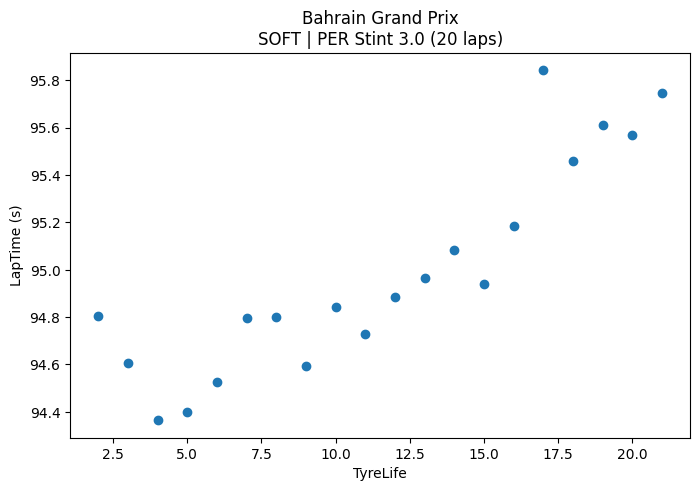

Driver: PER, Stint: 3.0, Laps: 20


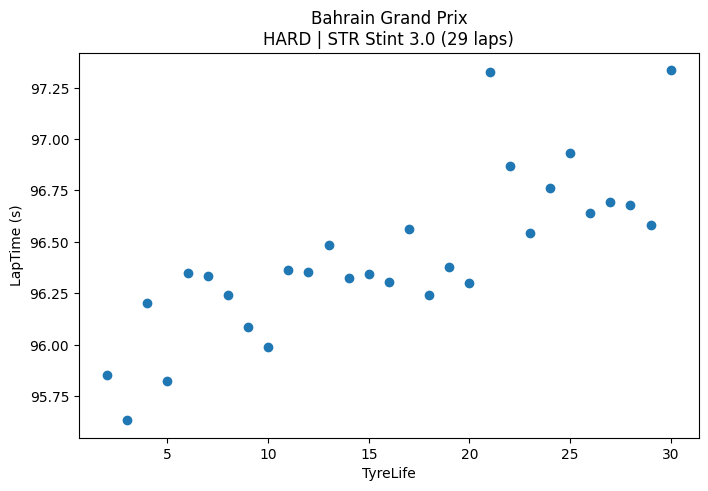

Driver: STR, Stint: 3.0, Laps: 29


IndexError: single positional indexer is out-of-bounds

In [31]:
plot_longest_stint(
    "Bahrain Grand Prix",
    "SOFT"
)

plot_longest_stint(
    "Bahrain Grand Prix",
    "HARD"
)

plot_longest_stint(
    "Bahrain Grand Prix",
    "MEDIUM"
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("degradation_dataset_2024_v1.csv")

def plot_longest_stint(gp, compound):

    sample = df[
        (df["GP"] == gp) &
        (df["Compound"] == compound)
    ]

    stint_lengths = (
        sample.groupby(
            ["Driver", "Stint"]
        )
        .size()
        .reset_index(name="Laps")
        .sort_values(
            "Laps",
            ascending=False
        )
    )
    

    best_driver = stint_lengths.iloc[0]["Driver"]
    best_stint = stint_lengths.iloc[0]["Stint"]
    best_laps = stint_lengths.iloc[0]["Laps"]

    stint_df = sample[
        (sample["Driver"] == best_driver) &
        (sample["Stint"] == best_stint)
    ]

    plt.figure(figsize=(8,5))

    plt.scatter(
        stint_df["TyreLife"],
        stint_df["LapTime"]
    )

    plt.xlabel("TyreLife")
    plt.ylabel("FuelCorrectedLapTime (s)")
    plt.title(
        f"{gp}\n"
        f"{compound} | "
        f"{best_driver} Stint {best_stint} "
        f"({best_laps} laps)"
    )

    plt.show()

    print(
        f"Driver: {best_driver}, "
        f"Stint: {best_stint}, "
        f"Laps: {best_laps}"
    )
    if sample.empty:
        print(f"No data found for {gp} - {compound}")
    return

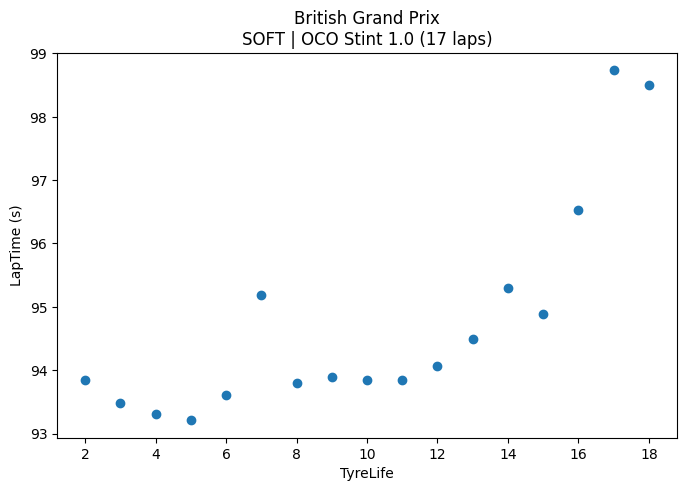

Driver: OCO, Stint: 1.0, Laps: 17


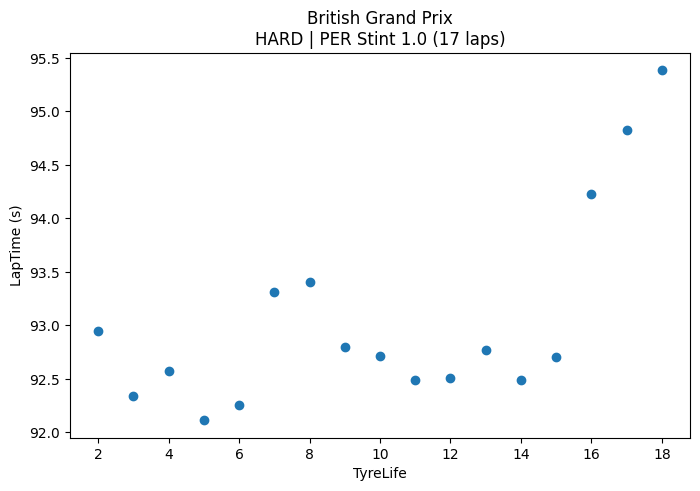

Driver: PER, Stint: 1.0, Laps: 17


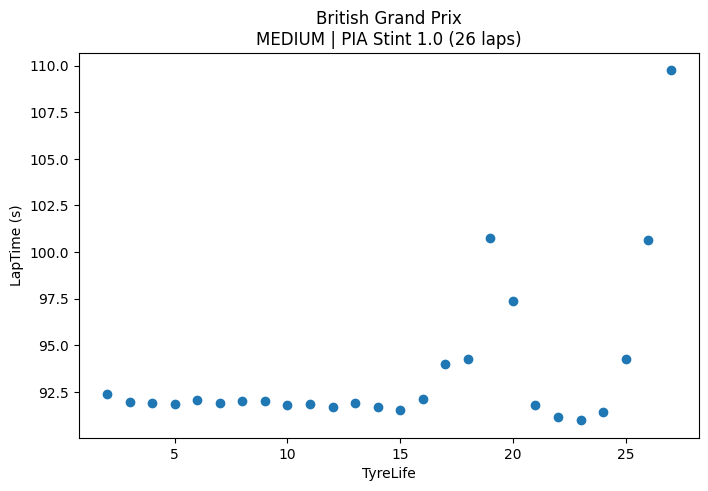

Driver: PIA, Stint: 1.0, Laps: 26


In [2]:
plot_longest_stint(
    "British Grand Prix",
    "SOFT"
)

plot_longest_stint(
    "British Grand Prix",
    "HARD"
)

plot_longest_stint(
    "British Grand Prix",
    "MEDIUM"
)

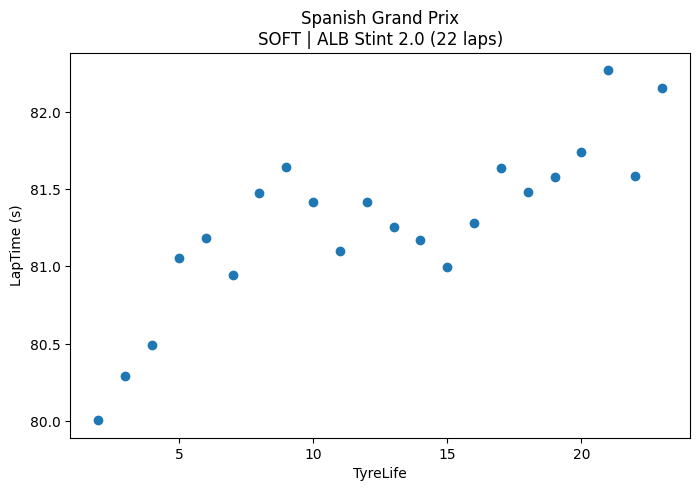

Driver: ALB, Stint: 2.0, Laps: 22


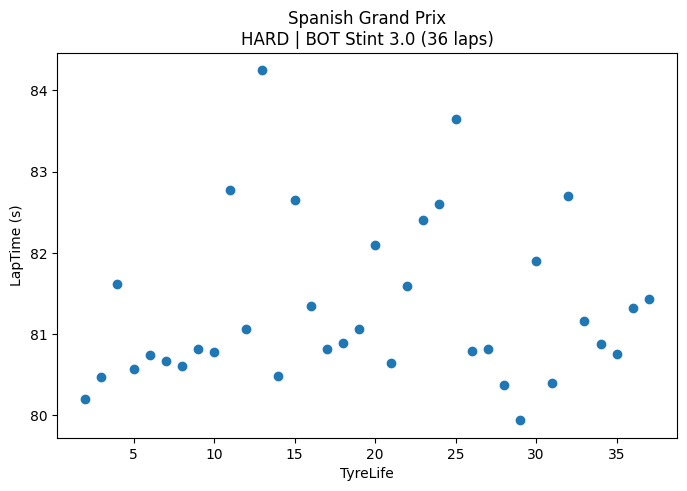

Driver: BOT, Stint: 3.0, Laps: 36


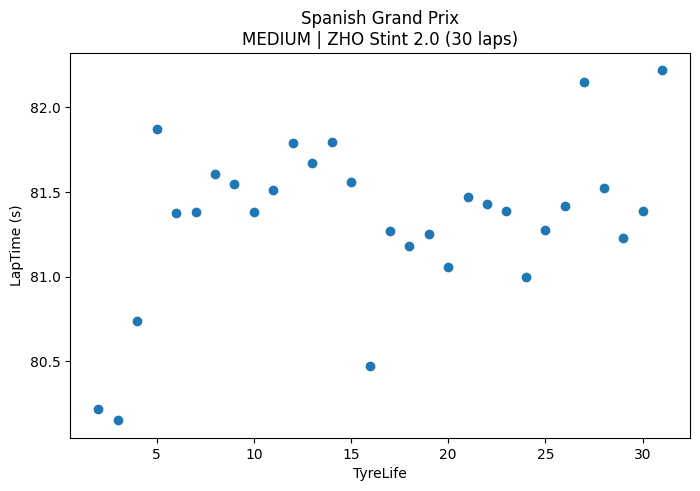

Driver: ZHO, Stint: 2.0, Laps: 30


In [3]:
plot_longest_stint(
    "Spanish Grand Prix",
    "SOFT"
)

plot_longest_stint(
    "Spanish Grand Prix",
    "HARD"
)

plot_longest_stint(
    "Spanish Grand Prix",
    "MEDIUM"
)

In [4]:
import pandas as pd

df = pd.read_csv(
    "degradation_dataset_2024_v1.csv"
)

# Best lap of each stint
df["BestLapInStint"] = (
    df.groupby(
        ["GP", "Driver", "Stint"]
    )["LapTime"]
    .transform("min")
)

# Tyre performance loss
df["TyreDelta"] = (
    df["LapTime"]
    - df["BestLapInStint"]
)

print(
    df[
        ["LapTime",
         "BestLapInStint",
         "TyreDelta"]
    ].head()
)

   LapTime  BestLapInStint  TyreDelta
0   96.296          96.296      0.000
1   96.753          96.296      0.457
2   96.647          96.296      0.351
3   97.173          96.296      0.877
4   97.092          96.296      0.796


In [1]:
import matplotlib.pyplot as plt

def plot_longest_stint_delta(gp, compound):

    sample = df[
        (df["GP"] == gp) &
        (df["Compound"] == compound)
    ]

    stint_lengths = (
        sample.groupby(
            ["Driver", "Stint"]
        )
        .size()
        .reset_index(name="Laps")
        .sort_values(
            "Laps",
            ascending=False
        )
    )

    if stint_lengths.empty:
        print("No data found")
        return

    best_driver = stint_lengths.iloc[0]["Driver"]
    best_stint = stint_lengths.iloc[0]["Stint"]

    stint_df = sample[
        (sample["Driver"] == best_driver) &
        (sample["Stint"] == best_stint)
    ]

    plt.figure(figsize=(8,5))

    plt.scatter(
        stint_df["TyreLife"],
        stint_df["TyreDelta"]
    )

    plt.xlabel("TyreLife")
    plt.ylabel("TyreDelta (s)")
    plt.title(
        f"{gp}\n"
        f"{compound} | "
        f"{best_driver} Stint {best_stint}"
    )

    plt.show()

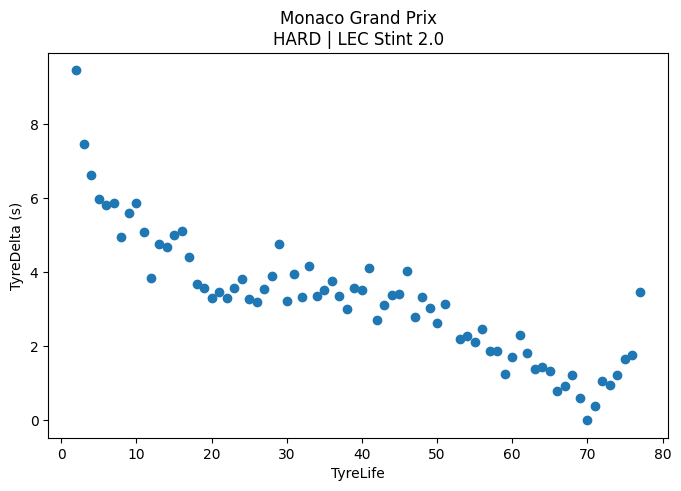

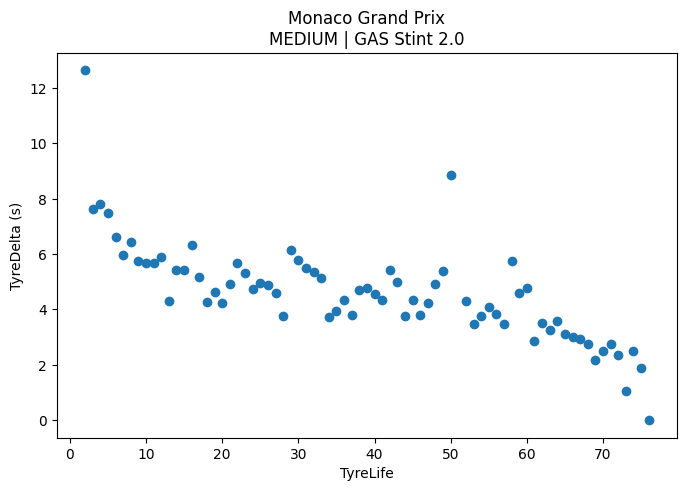

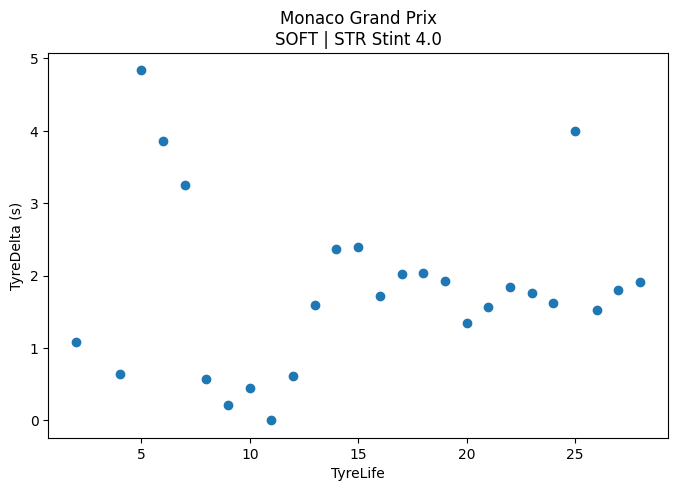

In [6]:
plot_longest_stint_delta(
    "Monaco Grand Prix",
    "HARD"
)

plot_longest_stint_delta(
    "Monaco Grand Prix",
    "MEDIUM"
)

plot_longest_stint_delta(
    "Monaco Grand Prix",
    "SOFT"
)

In [6]:
import pandas as pd

# -----------------------------------
# Load Degradation Dataset
# -----------------------------------

degrad_df = pd.read_csv(
    "degradation_dataset_2024_v1.csv"
)

# -----------------------------------
# Estimate Race Length
# -----------------------------------

race_lengths = (
    degrad_df
    .groupby("GP")["LapNumber"]
    .max()
    .reset_index()
    .rename(
        columns={
            "LapNumber": "RaceTotalLaps"
        }
    )
)

degrad_df = degrad_df.merge(
    race_lengths,
    on="GP",
    how="left"
)

# -----------------------------------
# Fuel Model
# -----------------------------------

INITIAL_FUEL = 109.0      # kg
FUEL_COST = 0.033         # sec/kg

# Fuel burned per lap

degrad_df["FuelBurnPerLap"] = (
    INITIAL_FUEL
    / degrad_df["RaceTotalLaps"]
)

# Remaining fuel

degrad_df["FuelRemaining"] = (
    INITIAL_FUEL
    - (
        (degrad_df["LapNumber"] - 1)
        * degrad_df["FuelBurnPerLap"]
    )
)

degrad_df["FuelRemaining"] = (
    degrad_df["FuelRemaining"]
    .clip(lower=0)
)

# Fuel time penalty

degrad_df["FuelPenalty"] = (
    degrad_df["FuelRemaining"]
    * FUEL_COST
)

# Fuel-corrected lap time

degrad_df["FuelCorrectedLapTime"] = (
    degrad_df["LapTime"]
    - degrad_df["FuelPenalty"]
)

# -----------------------------------
# Save Dataset
# -----------------------------------

degrad_df.to_csv(
    "degradation_dataset_2024_fuel_corrected.csv",
    index=False
)

print(
    degrad_df[
        [
            "GP",
            "LapNumber",
            "RaceTotalLaps",
            "FuelRemaining",
            "FuelPenalty",
            "LapTime",
            "FuelCorrectedLapTime"
        ]
    ].head(10)
)

                   GP  LapNumber  RaceTotalLaps  FuelRemaining  FuelPenalty  \
0  Bahrain Grand Prix          2             57     107.087719     3.533895   
1  Bahrain Grand Prix          3             57     105.175439     3.470789   
2  Bahrain Grand Prix          4             57     103.263158     3.407684   
3  Bahrain Grand Prix          5             57     101.350877     3.344579   
4  Bahrain Grand Prix          6             57      99.438596     3.281474   
5  Bahrain Grand Prix          7             57      97.526316     3.218368   
6  Bahrain Grand Prix          8             57      95.614035     3.155263   
7  Bahrain Grand Prix          9             57      93.701754     3.092158   
8  Bahrain Grand Prix         12             57      87.964912     2.902842   
9  Bahrain Grand Prix         13             57      86.052632     2.839737   

   LapTime  FuelCorrectedLapTime  
0   96.296             92.762105  
1   96.753             93.282211  
2   96.647             93

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("degradation_dataset_2024_v1.csv")

def plot_longest_stint(gp, compound):

    sample = df[
        (df["GP"] == gp) &
        (df["Compound"] == compound)
    ]

    stint_lengths = (
        sample.groupby(
            ["Driver", "Stint"]
        )
        .size()
        .reset_index(name="Laps")
        .sort_values(
            "Laps",
            ascending=False
        )
    )
    

    best_driver = stint_lengths.iloc[0]["Driver"]
    best_stint = stint_lengths.iloc[0]["Stint"]
    best_laps = stint_lengths.iloc[0]["Laps"]

    stint_df = sample[
        (sample["Driver"] == best_driver) &
        (sample["Stint"] == best_stint)
    ]

    plt.figure(figsize=(8,5))

    plt.scatter(
        stint_df["TyreLife"],
        stint_df["LapTime"]
    )

    plt.xlabel("TyreLife")
    plt.ylabel("FuelCorrectedLapTime (s)")
    plt.title(
        f"{gp}\n"
        f"{compound} | "
        f"{best_driver} Stint {best_stint} "
        f"({best_laps} laps)"
    )

    plt.show()

    print(
        f"Driver: {best_driver}, "
        f"Stint: {best_stint}, "
        f"Laps: {best_laps}"
    )
    if sample.empty:
        print(f"No data found for {gp} - {compound}")
    return

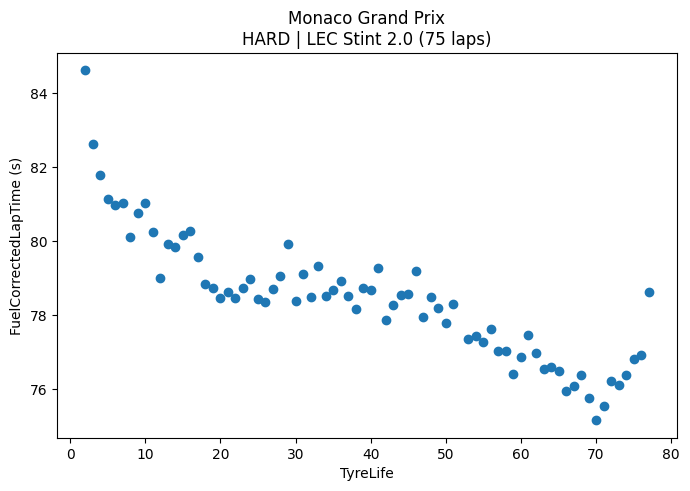

Driver: LEC, Stint: 2.0, Laps: 75


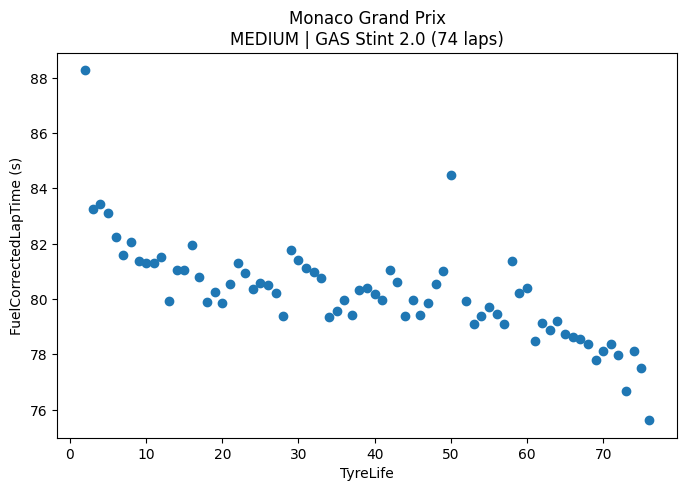

Driver: GAS, Stint: 2.0, Laps: 74


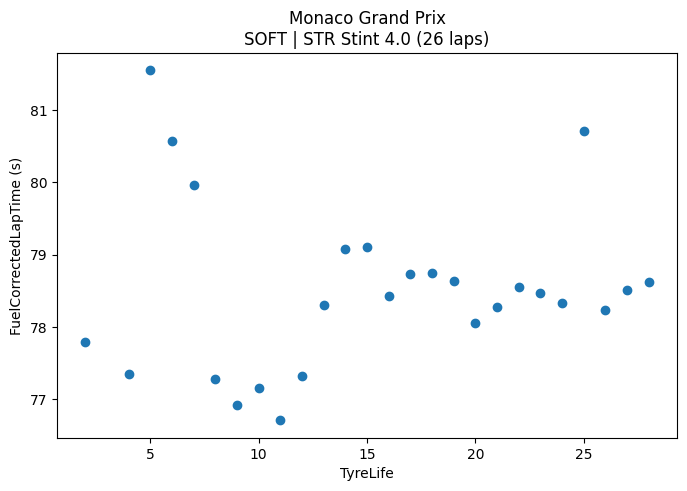

Driver: STR, Stint: 4.0, Laps: 26


In [8]:
plot_longest_stint(
    "Monaco Grand Prix",
    "HARD"
)
plot_longest_stint(
    "Monaco Grand Prix",
    "MEDIUM"
)
plot_longest_stint(
    "Monaco Grand Prix",
    "SOFT"
)

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load fuel-corrected dataset
degrad_df = pd.read_csv(
    "degradation_dataset_2024_fuel_corrected.csv"
)

def plot_longest_stint_fuel(gp, compound):

    # Filter GP + Compound
    sample = degrad_df[
        (degrad_df["GP"] == gp) &
        (degrad_df["Compound"] == compound)
    ].copy()

    if sample.empty:
        print(f"No data found for {gp} - {compound}")
        return

    # Find longest stint
    stint_lengths = (
        sample
        .groupby(["Driver", "Stint"])
        .size()
        .reset_index(name="Laps")
        .sort_values(
            "Laps",
            ascending=False
        )
    )

    best_driver = stint_lengths.iloc[0]["Driver"]
    best_stint = stint_lengths.iloc[0]["Stint"]
    best_laps = stint_lengths.iloc[0]["Laps"]

    # Extract that stint
    stint_df = sample[
        (sample["Driver"] == best_driver) &
        (sample["Stint"] == best_stint)
    ].copy()

    print(
        f"Driver: {best_driver} | "
        f"Stint: {best_stint} | "
        f"Laps: {best_laps}"
    )

    plt.figure(figsize=(8, 5))

    plt.scatter(
        stint_df["TyreLife"],
        stint_df["FuelCorrectedLapTime"]
    )

    plt.xlabel("TyreLife")
    plt.ylabel("Fuel Corrected LapTime (s)")
    plt.title(
        f"{gp}\n"
        f"{compound} | "
        f"{best_driver} Stint {best_stint} "
        f"({best_laps} laps)"
    )

    plt.grid(alpha=0.3)
    plt.show()

Driver: LEC | Stint: 2.0 | Laps: 75


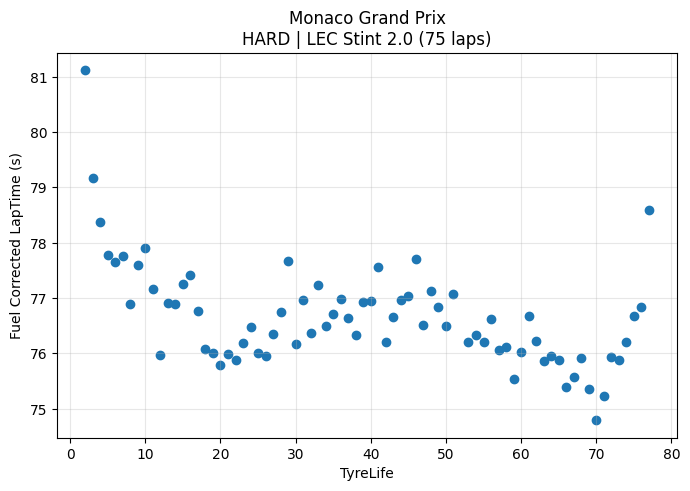

Driver: GAS | Stint: 2.0 | Laps: 74


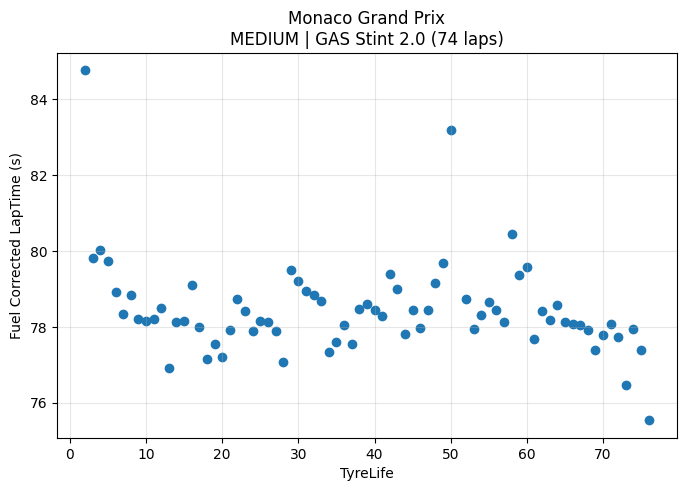

In [13]:
plot_longest_stint_fuel(
    "Monaco Grand Prix",
    "HARD"
)

plot_longest_stint_fuel(
    "Monaco Grand Prix",
    "MEDIUM"
)

In [2]:
import pandas as pd

# -----------------------------------
# Merge Track Features Into
# Master Stint Dataset
# -----------------------------------

def merge_track_features(
    master_stint_file,
    track_features_file,
    output_file
):

    # Load files
    master_df = pd.read_csv(
        master_stint_file
    )

    track_df = pd.read_csv(
        track_features_file
    )

    print(
        f"\nMaster Dataset Shape: {master_df.shape}"
    )

    print(
        f"Track Features Shape: {track_df.shape}"
    )

    # Merge
    merged_df = master_df.merge(
        track_df,
        on=["GP", "Driver", "Stint"],
        how="left"
    )

    # Fill missing values
    track_cols = [
        "YellowLaps",
        "SCLaps",
        "VSCLaps",
        "RedFlagLaps"
    ]

    merged_df[track_cols] = (
        merged_df[track_cols]
        .fillna(0)
        .astype(int)
    )

    print(
        f"Merged Dataset Shape: {merged_df.shape}"
    )

    print(
        "\nMissing Track Features:"
    )

    print(
        merged_df[track_cols]
        .isna()
        .sum()
    )

    # Save
    merged_df.to_csv(
        output_file,
        index=False
    )

    print(
        f"\nSaved: {output_file}"
    )

    return merged_df


# -----------------------------------
# 2023
# -----------------------------------

master_2023_v2 = merge_track_features(
    master_stint_file="C:/Users/VANSH/Formula1/datasets/2023/stints_master_2023.csv",
    track_features_file="track_features_2023.csv",
    output_file="master_stint_2023_v2.csv"
)

# -----------------------------------
# 2024
# -----------------------------------

master_2024_v2 = merge_track_features(
    master_stint_file="C:/Users/VANSH/Formula1/datasets/2024/stints_master_2024.csv",
    track_features_file="track_features_2024.csv",
    output_file="master_stint_2024_v2.csv"
)

# -----------------------------------
# Quick Check
# -----------------------------------

print(
    master_2023_v2[
        [
            "YellowLaps",
            "SCLaps",
            "VSCLaps",
            "RedFlagLaps"
        ]
    ].describe()
)

print(
    master_2024_v2[
        [
            "YellowLaps",
            "SCLaps",
            "VSCLaps",
            "RedFlagLaps"
        ]
    ].describe()
)


Master Dataset Shape: (1198, 9)
Track Features Shape: (2216, 7)
Merged Dataset Shape: (1198, 13)

Missing Track Features:
YellowLaps     0
SCLaps         0
VSCLaps        0
RedFlagLaps    0
dtype: int64

Saved: master_stint_2023_v2.csv

Master Dataset Shape: (1229, 9)
Track Features Shape: (2758, 7)
Merged Dataset Shape: (1229, 13)

Missing Track Features:
YellowLaps     0
SCLaps         0
VSCLaps        0
RedFlagLaps    0
dtype: int64

Saved: master_stint_2024_v2.csv
        YellowLaps       SCLaps      VSCLaps  RedFlagLaps
count  1198.000000  1198.000000  1198.000000  1198.000000
mean      1.629382     1.274624     0.469950     0.090985
std       2.314360     2.776655     1.120336     0.421917
min       0.000000     0.000000     0.000000     0.000000
25%       0.000000     0.000000     0.000000     0.000000
50%       1.000000     0.000000     0.000000     0.000000
75%       2.000000     1.000000     0.000000     0.000000
max      15.000000    21.000000     6.000000     4.000000
    

In [9]:
import fastf1
import pandas as pd
import numpy as np

fastf1.Cache.enable_cache("D:/F1-Tyre-Strategy-Engine data/f1_cache")

session = fastf1.get_session(
    2024,
    "Monaco Grand Prix",
    "Q"
)

session.load(telemetry=True)


core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.6.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Updating cache for _extended_timing_data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Cache updated!
req            INFO 	Updating cache for timing_app_data...
_api           INFO 	Fetching timing app data...
req            INFO 	Cache updated!
core           INFO 	Processing timing data...
req            INFO 	Updating cache for car_data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
req            INFO 	Cache updated!
req            INFO 	Updating cache for position_data...
_api           INFO 	Fetching position data...
_api           INFO 	Parsing po

In [10]:
lap = session.laps.pick_fastest()
telemetry = lap.get_telemetry()


In [12]:
speeds = telemetry["Speed"]
for p in [10, 15, 20, 25]:
    threshold = np.percentile(
        speeds,
        p
    )

    corner_speeds = speeds[
    speeds <= threshold
]

    avg_corner_speed = (
    corner_speeds.mean()
)

    print(avg_corner_speed)

64.61924682201904
70.95876943062167
75.22155832379788
79.62057555676583


In [25]:
import fastf1
import numpy as np


def get_corner_speed(
    season,
    gp_name,
    percentile=15
):

    session = fastf1.get_session(
        season,
        gp_name,
        "Q"
    )

    session.load()

    lap = (
        session.laps
        .pick_fastest()
    )

    telemetry = (
        lap.get_telemetry()
    )

    speeds = telemetry["Speed"]

    threshold = np.percentile(
        speeds,
        percentile
    )

    corner_speeds = speeds[
        speeds <= threshold
    ]

    return (
        corner_speeds.mean()
    )

In [30]:
df = pd.read_csv("C:/Users/VANSH/Formula1/datasets/circuit_metadata.csv", encoding="cp1252")
gps = sorted(
    df["GP"].unique()
)

results = []

for gp in gps:

    s23 = get_corner_speed(
        2023,
        gp
    )

    s24 = get_corner_speed(
        2024,
        gp
    )

    avg = (
        s23 + s24
    ) / 2

    results.append(
        {
            "GP": gp,
            "AverageCornerSpeed": round(
                avg,
                1
            )
        }
    )

core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.6.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '81', '63', '4', '22', '14', '27', '11', '10', '44', '31', '18', '23', '3', '55', '20', '77', '24', '2']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.6.0]
req            INFO 	Using

In [31]:
corner_df = pd.DataFrame(
    results
)

corner_df.to_csv(
    "average_corner_speed.csv",
    index=False
)

In [24]:
speed_2023 = get_corner_speed(
    2023,
    "Bahrain Grand Prix"
)

speed_2024 = get_corner_speed(
    2024,
    "Bahrain Grand Prix"
)

avg_speed = (
    speed_2023 +
    speed_2024
) / 2

print(avg_speed)

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.6.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '55', '14', '63', '44', '18', '31', '27', '4', '77', '24', '22', '23', '2', '20', '81', '21', '10']
core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.6.0]
req            INFO 	Using ca

108.17202586837683


In [47]:
import pandas as pd

metadata = pd.read_csv("C:/Users/VANSH/Formula1/datasets/circuit_metadata.csv", encoding="cp1252")

corner_speed = pd.read_csv(
    "average_corner_speed.csv",
    encoding="cp1252"
)

metadata = metadata.merge(
    corner_speed,
    on="GP",
    how="left"
)

print(
    metadata.isna().sum()
)

metadata.to_csv(
    "circuit_metadata.csv",
    index=False
)

print(
    "Circuit metadata updated successfully."
)

GP                      0
CircuitType             0
TrackLength             0
TrackAbrasiveness       0
AverageCornerSpeed_x    0
AverageCornerSpeed_y    0
dtype: int64
Circuit metadata updated successfully.


In [48]:
pd.read_csv("C:/Users/VANSH/Formula1/datasets/circuit_metadata.csv", encoding="cp1252")
print(
    metadata.sort_values(
        "AverageCornerSpeed"
    )[
        ["GP", "AverageCornerSpeed"]
    ]
)

KeyError: 'AverageCornerSpeed'

In [41]:
import fastf1

session = fastf1.get_session(
    2024,
    "São Paulo Grand Prix",
    "Q"
)

session.load()

core           INFO 	Loading data for São Paulo Grand Prix - Qualifying [v3.6.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '23'
core        WARNING 	Fixed incorrect tyre stint information for driver '55'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '63', '22', '31', '30', '16', '23', '81', '14', '18', '77', '1', '

In [44]:
def get_corner_speed(
    season,
    gp_name,
    percentile=15
):

    try:
        session = fastf1.get_session(
            season,
            gp_name,
            "Q"
        )

        session.load()

        lap = session.laps.pick_fastest()

        telemetry = lap.get_telemetry()

        if telemetry.empty:
            return None

        speeds = telemetry["Speed"]

        threshold = np.percentile(
            speeds,
            percentile
        )

        corner_speeds = speeds[
            speeds <= threshold
        ]

        return corner_speeds.mean()

    except Exception as e:
        print(
            f"{gp_name} {season}: {e}"
        )
        return None

In [45]:
s23 = get_corner_speed(
    2023,
    "São Paulo Grand Prix"
)

s24 = get_corner_speed(
    2024,
    "São Paulo Grand Prix"
)

print(s23)
print(s24)

core           INFO 	Loading data for São Paulo Grand Prix - Qualifying [v3.6.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '18', '14', '44', '63', '4', '55', '11', '81', '27', '31', '10', '20', '23', '22', '3', '77', '2', '24']
core           INFO 	Loading data for São Paulo Grand Prix - Qualifying [v3.6.0]
req            INFO 	Using

108.82879134868345
87.27776248063049
